# Introduction

Nama : Hernanda Rifaldi

Batch : HCK-037

Objektif : Membikin model dan juga mengevaluasi model yang berguna untuk memprediksi kedepresian seseorang

# Import Libraries

In [2]:
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
import scipy.stats as st

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Data Loading

In [3]:
df_raw = pd.read_csv('student_depression_dataset.csv')
display(df_raw.head())
print("Shape:", df_raw.shape)
df_raw.info()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


Shape: (27901, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-nu

In [4]:
def to_snake(s: str) -> str:
    s = s.strip().lower()
    s = s.replace("/", " ")
    s = s.replace("?", "")
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    # bersihkan apostrof pada data kategorikal
    for c in df.select_dtypes(include="object").columns:
        df[c] = df[c].astype(str).str.strip().str.strip("'").str.strip()

    # Financial Stress: '?' -> NaN lalu float
    if "Financial Stress" in df.columns:
        df["Financial Stress"] = df["Financial Stress"].replace("?", np.nan).astype(float)

    # rename ke snake_case
    df = df.rename(columns={c: to_snake(c) for c in df.columns})

    # pendekkan nama kolom yang kepanjangan
    rename_map = {
        "have_you_ever_had_suicidal_thoughts": "suicidal_thoughts",
        "family_history_of_mental_illness": "family_history_mental_illness",
        "work_study_hours": "work_study_hours",  # tetap
    }
    df = df.rename(columns=rename_map)

    return df

df = clean_dataset(df_raw)

print("Cek missing values (top 10):")
display(df.isna().sum().sort_values(ascending=False).head(10))
df.head()

Cek missing values (top 10):


financial_stress                 3
id                               0
gender                           0
family_history_mental_illness    0
work_study_hours                 0
suicidal_thoughts                0
degree                           0
dietary_habits                   0
sleep_duration                   0
job_satisfaction                 0
dtype: int64

,id,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work_study_hours,financial_stress,family_history_mental_illness,depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


# EDA

,count
depression,
0,11565
1,16336


,proportion
depression,
0,0.414501
1,0.585499


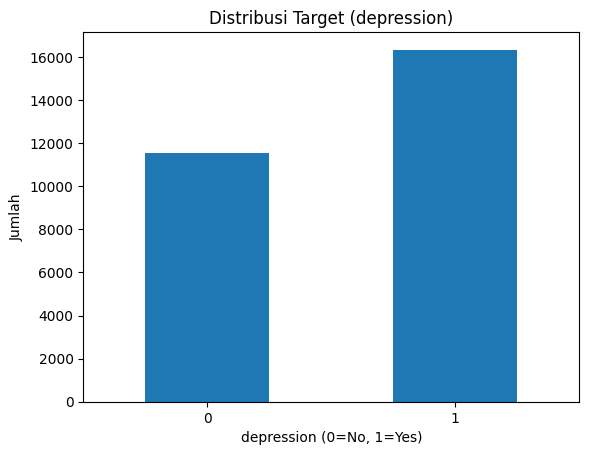

In [5]:
target_col = "depression"
counts = df[target_col].value_counts().sort_index()
props = df[target_col].value_counts(normalize=True).sort_index()

display(counts.to_frame("count"))
display(props.to_frame("proportion"))

plt.figure()
counts.plot(kind="bar")
plt.title("Distribusi Target (depression)")
plt.xlabel("depression (0=No, 1=Yes)")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

# Distribusi Depresi berdasarkan feature yang lain

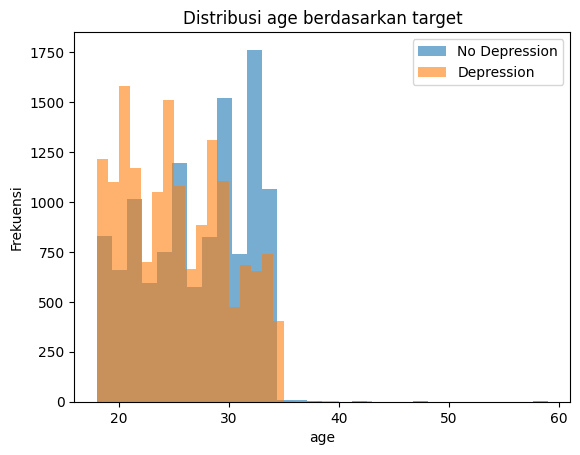

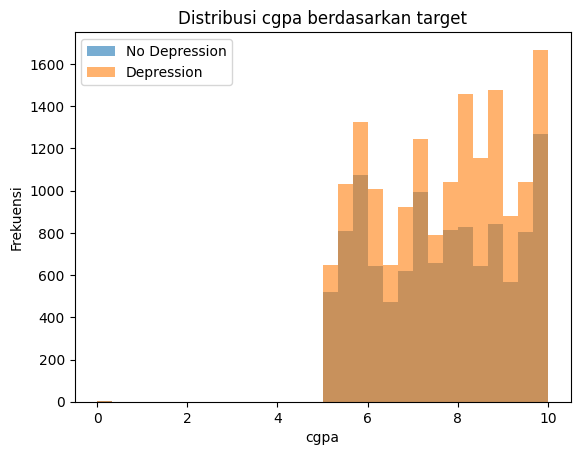

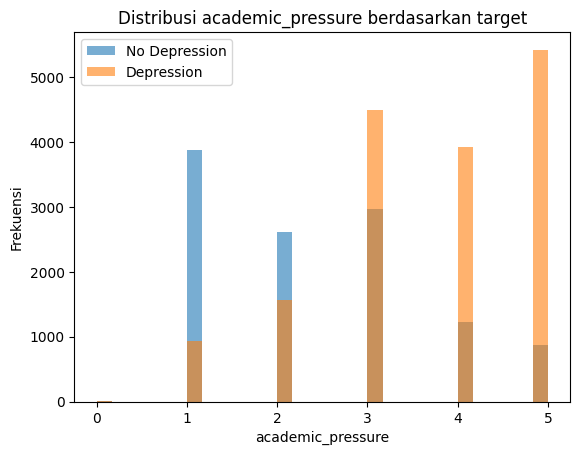

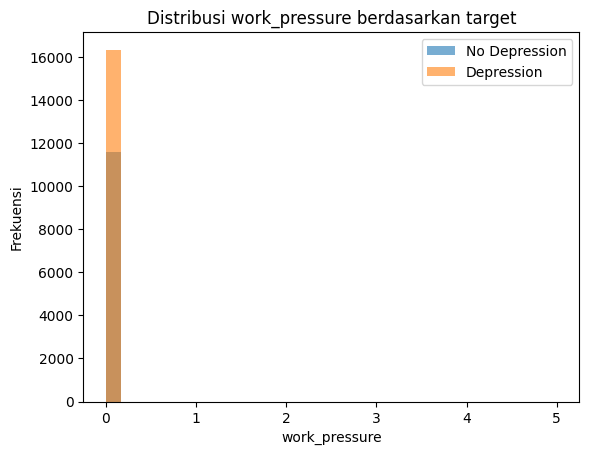

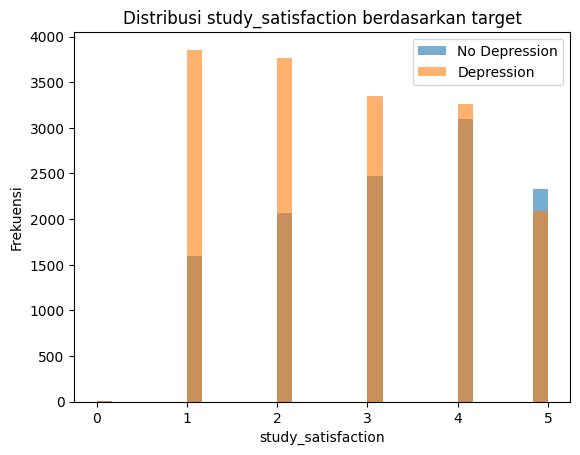

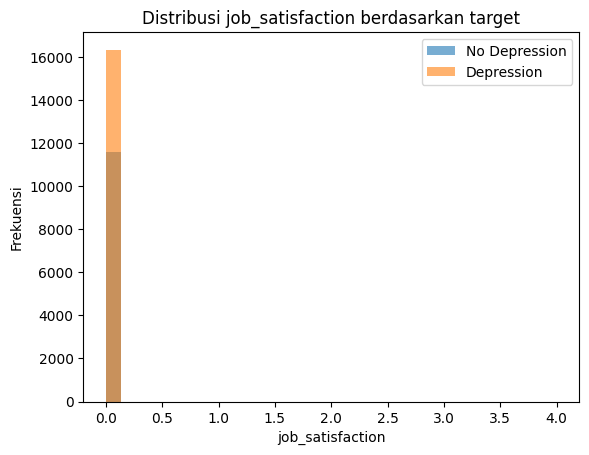

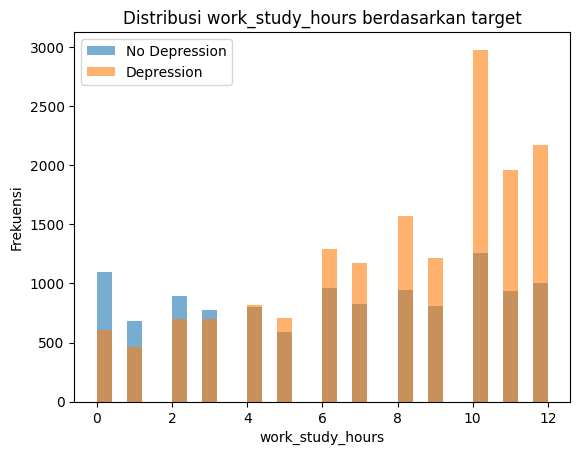

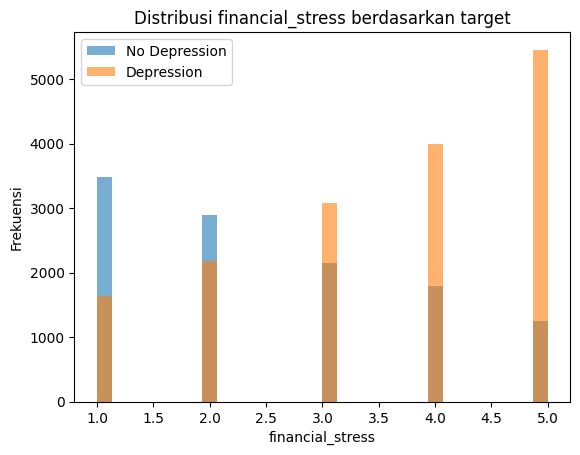

In [6]:
num_cols_preview = [
    "age","cgpa","academic_pressure","work_pressure",
    "study_satisfaction","job_satisfaction","work_study_hours","financial_stress"
]
num_cols_preview = [c for c in num_cols_preview if c in df.columns]

for col in num_cols_preview:
    plt.figure()
    df[df[target_col] == 0][col].plot(kind="hist", bins=30, alpha=0.6, label="No Depression")
    df[df[target_col] == 1][col].plot(kind="hist", bins=30, alpha=0.6, label="Depression")
    plt.title(f"Distribusi {col} berdasarkan target")
    plt.xlabel(col); plt.ylabel("Frekuensi")
    plt.legend()
    plt.show()

financial_stress: makin tinggi (4–5) makin banyak yang Depression; level rendah (1–2) lebih banyak No Depression.

academic_pressure: pola mirip—level tinggi (4–5) didominasi Depression, level rendah (1–2) cenderung No Depression.

work_study_hours: jam belajar/kerja yang tinggi (±6–12 jam, terutama 10–12) lebih sering muncul di Depression; jam rendah lebih banyak No Depression.

study_satisfaction: kepuasan rendah (1–2) lebih banyak Depression; makin tinggi kepuasan, makin condong ke No Depression.

cgpa: distribusinya mirip antara dua kelas → bukan pembeda kuat.

age: Depression lebih banyak di usia lebih muda (sekitar awal 20-an), sedangkan No Depression lebih banyak di akhir 20–awal 30-an (tapi tetap overlap).

## Heatmap Korelasi

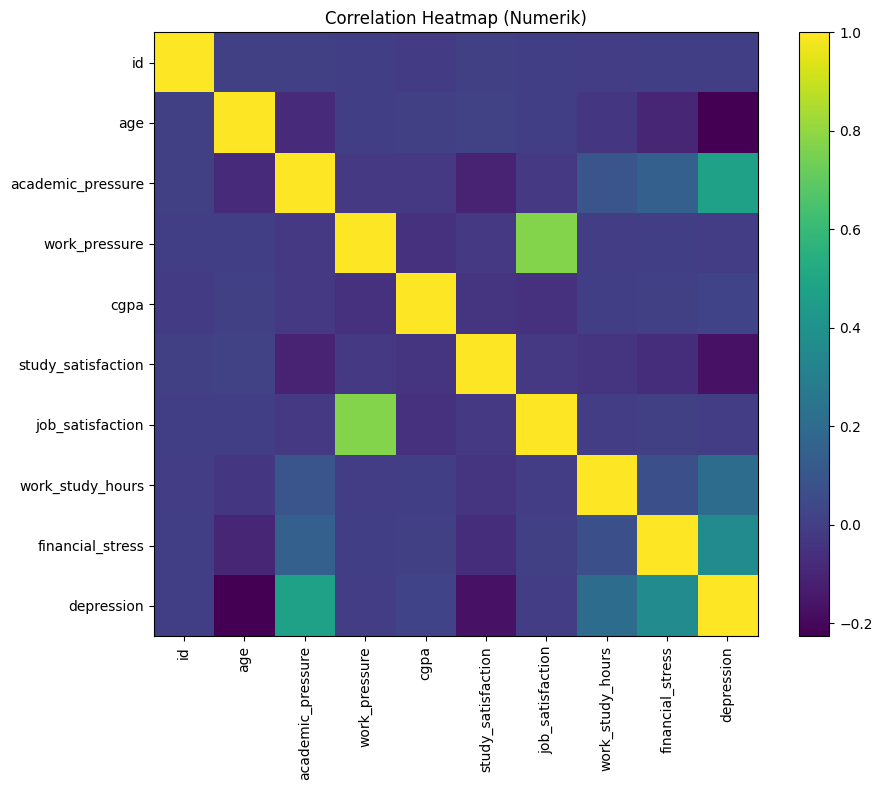

In [7]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Heatmap (Numerik)")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.tight_layout()
plt.show()

Gambar tersebut merupakan correlation heatmap untuk fitur numerik. Warna yang semakin terang menunjukkan korelasi positif yang semakin kuat, sedangkan warna yang semakin gelap/ungu menunjukkan korelasi negatif, dan warna mendekati biru tua berarti korelasinya lemah atau mendekati nol. Dari heatmap terlihat bahwa academic_pressure dan financial_stress memiliki korelasi positif terhadap depression, artinya ketika tekanan akademik atau stres finansial meningkat, nilai depresi cenderung ikut meningkat. Selain itu, work_study_hours juga menunjukkan korelasi positif walaupun tidak terlalu kuat terhadap depresi. Sementara itu, age dan study_satisfaction cenderung berkorelasi negatif terhadap depression, yang mengindikasikan bahwa semakin tinggi usia atau semakin puas terhadap studi, tingkat depresi cenderung lebih rendah. Korelasi pada kolom id tidak terlalu bermakna karena hanya merupakan nomor penanda data

## Depression rate by all col

,depression_rate
gender,
Male,0.586287
Female,0.584507


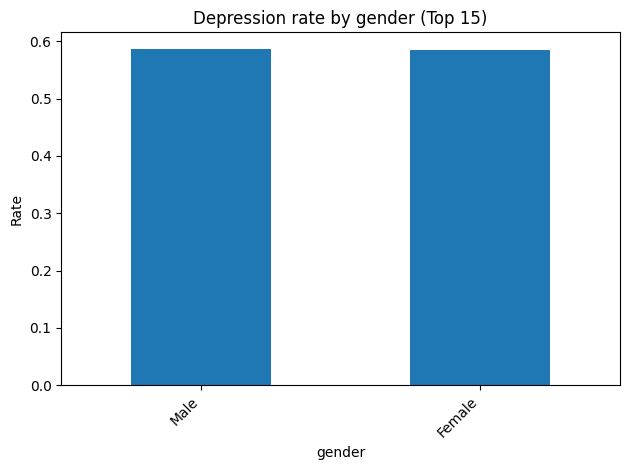

,depression_rate
sleep_duration,
Less than 5 hours,0.645126
7-8 hours,0.595018
5-6 hours,0.568818
More than 8 hours,0.509265
Others,0.500000


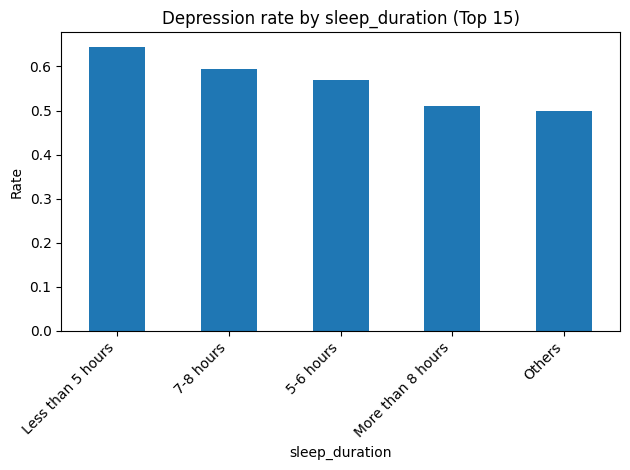

,depression_rate
dietary_habits,
Unhealthy,0.707279
Others,0.666667
Moderate,0.560226
Healthy,0.453928


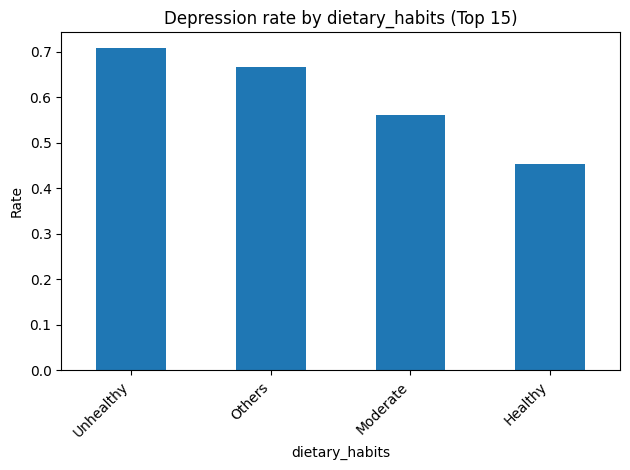

,depression_rate
suicidal_thoughts,
Yes,0.790496
No,0.232211


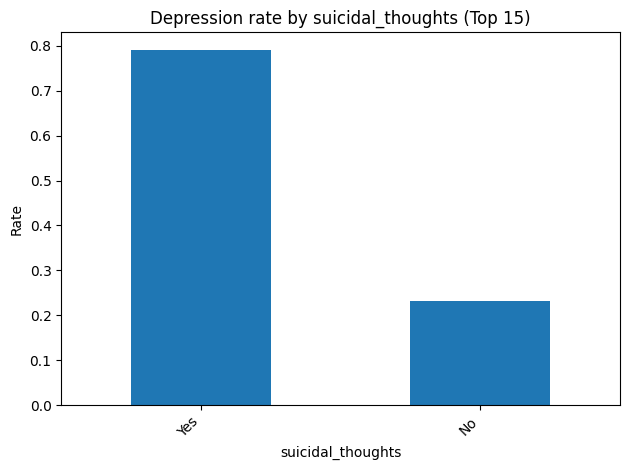

,depression_rate
family_history_mental_illness,
Yes,0.612679
No,0.560008


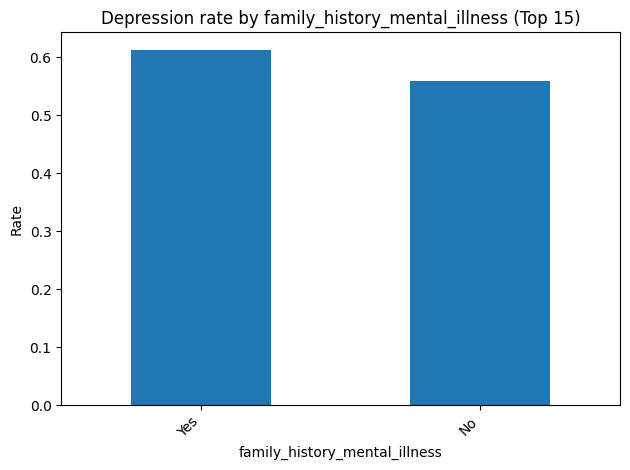

,depression_rate
profession,
Chef,1.000000
Civil Engineer,1.000000
Content Writer,1.000000
Doctor,1.000000
Educational Consultant,1.000000
Entrepreneur,1.000000
Lawyer,1.000000
Manager,1.000000
Pharmacist,1.000000


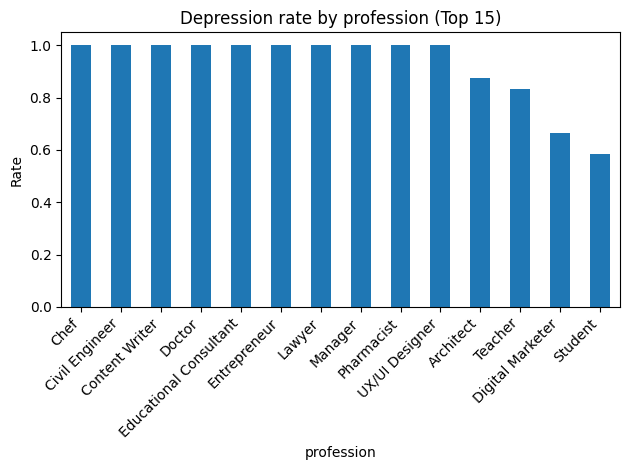

,depression_rate
degree,
Class 12,0.707730
Others,0.600000
B.Arch,0.589310
BSc,0.588964
BBA,0.584770
MBBS,0.580460
BCA,0.571528
MSc,0.570588
B.Tech,0.568576


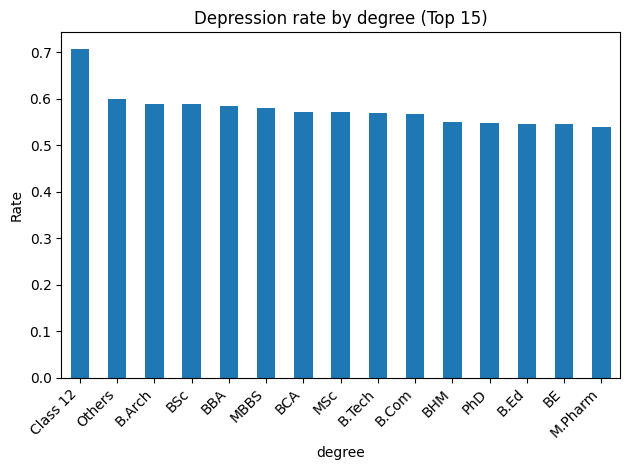

In [8]:
cat_cols_preview = [
    "gender","sleep_duration","dietary_habits",
    "suicidal_thoughts","family_history_mental_illness","profession","degree"
]
cat_cols_preview = [c for c in cat_cols_preview if c in df.columns]

for col in cat_cols_preview:
    rate = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    display(rate.to_frame("depression_rate").head(15))

    plt.figure()
    rate.head(15).plot(kind="bar")
    plt.title(f"Depression rate by {col} (Top 15)")
    plt.xlabel(col); plt.ylabel("Rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Gender: Tingkat depresi pada Male (0.586) dan Female (0.585) hampir sama, jadi gender tidak terlihat sebagai pembeda kuat di data ini.

Sleep Duration: Depresi cenderung lebih tinggi pada yang tidur <5 jam (0.645), lalu menurun pada 7–8 jam (0.595) dan 5–6 jam (0.569), dan paling rendah pada >8 jam (0.509). Ini mengindikasikan pola bahwa tidur lebih cukup berkaitan dengan depresi yang lebih rendah.

Dietary Habits: Pola paling jelas terlihat di pola makan. Unhealthy (0.707) paling tinggi, lalu Moderate (0.560), dan paling rendah Healthy (0.454). Artinya pola makan tidak sehat berkaitan dengan risiko depresi lebih tinggi.

Suicidal Thoughts: Ini faktor yang paling “kontras”. Kategori Yes (0.790) jauh lebih tinggi dibanding No (0.232). Ini menunjukkan bahwa pikiran bunuh diri sangat berkaitan dengan tingkat depresi yang tinggi pada dataset.

Family History of Mental Illness: Ada perbedaan, tapi tidak terlalu besar. Yes (0.613) sedikit lebih tinggi dibanding No (0.560), jadi riwayat keluarga berasosiasi dengan depresi namun efeknya moderat.

Profession: Banyak profesi yang tampil 1.0 (100%), kemungkinan besar karena jumlah sampelnya sangat sedikit (misalnya hanya 1–2 orang), sehingga tidak stabil untuk disimpulkan. Yang lebih aman dilihat: Student (0.585) ada di sekitar rata-rata dataset, sedangkan beberapa profesi seperti Teacher (0.833) dan Architect (0.875) terlihat tinggi tapi tetap perlu cek jumlah datanya dulu.

Degree: Tingkat depresi cukup bervariasi. Yang relatif tinggi: Class 12 (0.708). Yang lebih rendah: M.Pharm (0.540), BE (0.545), B.Ed (0.547), PhD (0.548). Perbedaannya ada, tetapi tidak sedrastis variabel “suicidal_thoughts” atau “dietary_habits”.

# Feature Engineering

## Split data

In [9]:
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# id biasanya identifier
if "id" in X.columns:
    X = X.drop(columns=["id"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)
display(y_train.value_counts(normalize=True).sort_index().to_frame("train_prop"))

Train: (22320, 16) Test: (5581, 16)


,train_prop
depression,
0,0.414516
1,0.585484


## Preprocessing

In [10]:
num_features = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object","bool"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop"
)

print("Num features:", num_features)
print("Cat features:", cat_features)

Num features: ['age', 'academic_pressure', 'work_pressure', 'cgpa', 'study_satisfaction', 'job_satisfaction', 'work_study_hours', 'financial_stress']
Cat features: ['gender', 'city', 'profession', 'sleep_duration', 'dietary_habits', 'degree', 'suicidal_thoughts', 'family_history_mental_illness']


fitur kategorikal (object/bool) akan diproses dengan mengisi nilai kosong menggunakan nilai yang paling sering muncul (most_frequent) lalu diubah menjadi bentuk numerik dengan OneHotEncoder yang aman untuk kategori baru karena handle_unknown="ignore". Semua proses tersebut digabungkan dalam ColumnTransformer bernama preprocess agar preprocessing numerik dan kategorikal berjalan otomatis sesuai kolomnya, sedangkan kolom lain di luar daftar akan dihapus karena remainder="drop".

# Model Definition

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy":"accuracy", "f1":"f1", "roc_auc":"roc_auc"}

pipelines = {
        "KNN": Pipeline([("preprocess", preprocess), ("model", KNeighborsClassifier())]),
        "SVM": Pipeline([("preprocess", preprocess), ("model", LinearSVC(random_state=42, max_iter=5000))]),
        "DecisionTree": Pipeline([("preprocess", preprocess), ("model", DecisionTreeClassifier(random_state=42))]),
        "RandomForest": Pipeline([("preprocess", preprocess), ("model", RandomForestClassifier(random_state=42, n_estimators=300))]),
        "AdaBoost": Pipeline([("preprocess", preprocess), ("model", AdaBoostClassifier(random_state=42))]),
}

KNN (K-Nearest Neighbors)
Dipakai sebagai baseline sederhana: prediksi berdasarkan “tetangga terdekat” di ruang fitur. Bagus untuk melihat apakah pola data bisa dipisahkan dengan kedekatan. Sensitif terhadap scaling, makanya cocok digabung StandardScaler.

SVM (LinearSVC)
Bagus untuk data yang setelah one-hot bisa jadi dimensi tinggi. Linear SVM sering kuat untuk klasifikasi dengan banyak fitur (hasil one-hot) dan cenderung stabil. Dipilih LinearSVC karena lebih cepat/efisien dibanding SVM kernel untuk fitur banyak.

Decision Tree
Mudah diinterpretasi dan bisa menangkap hubungan non-linear. Dipakai sebagai pembanding karena tree bisa “membelah” aturan keputusan, tapi rawan overfitting kalau tidak dibatasi.

Random Forest
Versi “lebih kuat” dari decision tree: gabungan banyak tree untuk mengurangi overfitting dan biasanya performanya bagus di banyak kasus tabular. Cocok untuk menangkap pola non-linear dan interaksi fitur.

AdaBoost
Model ensemble yang “menguatkan” model lemah secara bertahap. Sering bagus untuk data tabular dan bisa meningkatkan performa dibanding satu tree saja, terutama kalau pola cukup kompleks.

# Model Training

In [12]:
X_sel, y_sel = X_train, y_train
print("Selection set:", X_sel.shape)

Selection set: (22320, 16)


## Cross Validation

In [13]:
cv_rows = []
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_sel, y_sel, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "model": name,
        "acc_mean": scores["test_accuracy"].mean(),
        "acc_std": scores["test_accuracy"].std(),
        "f1_mean": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)
display(cv_results)

,model,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,SVM,0.847760,0.002473,0.872408,0.002101,0.921304,0.002324
1,AdaBoost,0.845833,0.002799,0.870536,0.002378,0.920313,0.002123
2,RandomForest,0.842697,0.001522,0.868387,0.001418,0.913925,0.002683
3,KNN,0.819041,0.004011,0.849880,0.003254,0.875729,0.004774
4,DecisionTree,0.775224,0.005557,0.808062,0.004825,0.768432,0.005702


## Hyperparameter Tuning

In [14]:
param_distributions = {
    "SVM": {"model__C": st.loguniform(1e-3, 1e2)},
    "RandomForest": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "AdaBoost": {
        "model__n_estimators": [100, 200, 400],
        "model__learning_rate": st.uniform(0.01, 1.0),
    },
    "KNN": {
        "model__n_neighbors": list(range(3, 31, 2)),
        "model__weights": ["uniform", "distance"],
    }
}

search_list = ["SVM", "RandomForest", "AdaBoost", "KNN"]
best_estimators = {}
tuning_rows = []

for name in search_list:
    search = RandomizedSearchCV(
        pipelines[name],
        param_distributions=param_distributions[name],
        n_iter=15,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_sel, y_sel)
    best_estimators[name] = search.best_estimator_
    tuning_rows.append({"model": name, "best_f1_cv": search.best_score_, "best_params": search.best_params_})

tuning_results = pd.DataFrame(tuning_rows).sort_values("best_f1_cv", ascending=False).reset_index(drop=True)
display(tuning_results)

,model,best_f1_cv,best_params
0,AdaBoost,0.873735,"{'model__learning_rate': 0.3012291401980419, '..."
1,SVM,0.873005,{'model__C': 0.008111941985431923}
2,KNN,0.869417,"{'model__weights': 'distance', 'model__n_neigh..."
3,RandomForest,0.868449,"{'model__n_estimators': 400, 'model__min_sampl..."


In [15]:
cv_rows = []
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_sel, y_sel, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "model": name,
        "acc_mean": scores["test_accuracy"].mean(),
        "acc_std": scores["test_accuracy"].std(),
        "f1_mean": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)
display(cv_results)

,model,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,SVM,0.847760,0.002473,0.872408,0.002101,0.921304,0.002324
1,AdaBoost,0.845833,0.002799,0.870536,0.002378,0.920313,0.002123
2,RandomForest,0.842697,0.001522,0.868387,0.001418,0.913925,0.002683
3,KNN,0.819041,0.004011,0.849880,0.003254,0.875729,0.004774
4,DecisionTree,0.775224,0.005557,0.808062,0.004825,0.768432,0.005702


In [16]:
search_list = ["SVM", "RandomForest", "AdaBoost", "KNN"]
best_estimators = {}
tuning_rows = []

for name in search_list:
    search = RandomizedSearchCV(
        pipelines[name],
        param_distributions=param_distributions[name],
        n_iter=15,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_sel, y_sel)

    best_estimators[name] = search.best_estimator_

    tuning_rows.append({
        "model": name,
        "best_f1_cv": search.best_score_,
        "best_f1_std": search.cv_results_["std_test_score"][search.best_index_],
        "best_params": search.best_params_
    })

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values("best_f1_cv", ascending=False)
    .reset_index(drop=True)
)

display(tuning_results)

,model,best_f1_cv,best_f1_std,best_params
0,AdaBoost,0.873735,0.002074,"{'model__learning_rate': 0.3012291401980419, '..."
1,SVM,0.873005,0.001989,{'model__C': 0.008111941985431923}
2,KNN,0.869417,0.001572,"{'model__weights': 'distance', 'model__n_neigh..."
3,RandomForest,0.868449,0.001854,"{'model__n_estimators': 400, 'model__min_sampl..."


# Model Evaluation

Best model: AdaBoost
              precision    recall  f1-score   support

           0     0.8318    0.7890    0.8099      2313
           1     0.8559    0.8871    0.8712      3268

    accuracy                         0.8464      5581
   macro avg     0.8439    0.8381    0.8405      5581
weighted avg     0.8459    0.8464    0.8458      5581



<Figure size 640x480 with 0 Axes>

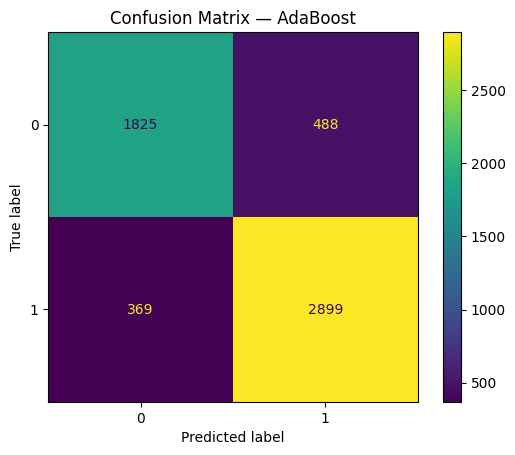

<Figure size 640x480 with 0 Axes>

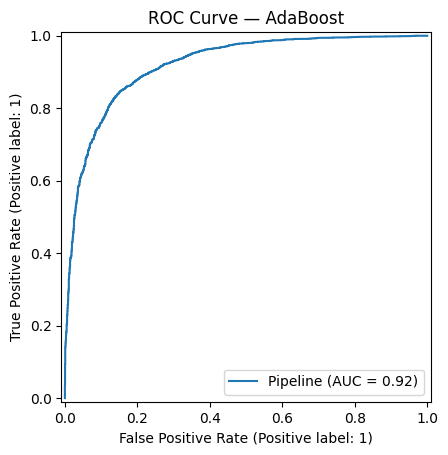

In [17]:
if len(tuning_results) > 0:
    best_name = tuning_results.loc[0, "model"]
    best_model = best_estimators[best_name]
else:
    best_name = cv_results.loc[0, "model"]
    best_model = pipelines[best_name]

print("Best model:", best_name)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

plt.figure()
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

plt.figure()
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"ROC Curve — {best_name}")
plt.show()

Model adaboost menunjukkan performa yang cukup baik pada data test dengan accuracy. Untuk kelas Depression, model memiliki recall dan f1-score, yang berarti model mampu menangkap sebagian besar kasus depresi (false negative relatif rendah/tinggi). Namun precision kelas Depression sebesar {prec1} menunjukkan masih ada/mulai berkurang prediksi depresi yang ternyata tidak depresi (false positive). Secara keseluruhan, model sudah layak.

# Model Saving

In [18]:
from pathlib import Path
import joblib

Path("artifacts").mkdir(exist_ok=True)
joblib.dump(best_model, "artifacts/best_model.joblib")

['artifacts/best_model.joblib']